Step 1: Import the Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
%matplotlib inline

Step 2: Import the Datasets

In [3]:
cab_rides_data = pd.read_csv('./Dataset/cab_rides.csv')
weather_data = pd.read_csv('./Dataset/weather.csv')

In [4]:
cab_rides_data.head(5)

,distance,cab_type,time_stamp,destination,source,price,surge_multiplier,id,product_id,name
0,0.44,Lyft,1544952607890,North Station,Haymarket Square,5.0,1.0,424553bb-7174-41ea-aeb4-fe06d4f4b9d7,lyft_line,Shared
1,0.44,Lyft,1543284023677,North Station,Haymarket Square,11.0,1.0,4bd23055-6827-41c6-b23b-3c491f24e74d,lyft_premier,Lux
2,0.44,Lyft,1543366822198,North Station,Haymarket Square,7.0,1.0,981a3613-77af-4620-a42a-0c0866077d1e,lyft,Lyft
3,0.44,Lyft,1543553582749,North Station,Haymarket Square,26.0,1.0,c2d88af2-d278-4bfd-a8d0-29ca77cc5512,lyft_luxsuv,Lux Black XL
4,0.44,Lyft,1543463360223,North Station,Haymarket Square,9.0,1.0,e0126e1f-8ca9-4f2e-82b3-50505a09db9a,lyft_plus,Lyft XL


In [5]:
weather_data.head(5)

,temp,location,clouds,pressure,rain,time_stamp,humidity,wind
0,42.42,Back Bay,1.0,1012.14,0.1228,1545003901,0.77,11.25
1,42.43,Beacon Hill,1.0,1012.15,0.1846,1545003901,0.76,11.32
2,42.50,Boston University,1.0,1012.15,0.1089,1545003901,0.76,11.07
3,42.11,Fenway,1.0,1012.13,0.0969,1545003901,0.77,11.09
4,43.13,Financial District,1.0,1012.14,0.1786,1545003901,0.75,11.49


Step 3: Preprocess and Format Timestamps

In [6]:
cab_rides_data['datetime'] = pd.to_datetime(cab_rides_data['time_stamp'], unit='ms')
weather_data['datetime'] = pd.to_datetime(weather_data['time_stamp'], unit='s')

In [7]:
cab_rides_data['hour'] = cab_rides_data['datetime'].dt.hour
cab_rides_data['day_of_week'] = cab_rides_data['datetime'].dt.day_name()

In [8]:
cab_rides_data['time_hour'] = cab_rides_data['datetime'].dt.round('h')
weather_data['time_hour'] = weather_data['datetime'].dt.round('h')

In [9]:
print(cab_rides_data[['time_stamp', 'datetime', 'hour', 'day_of_week', 'time_hour']].head())

      time_stamp                datetime  hour day_of_week           time_hour
0  1544952607890 2018-12-16 09:30:07.890     9      Sunday 2018-12-16 10:00:00
1  1543284023677 2018-11-27 02:00:23.677     2     Tuesday 2018-11-27 02:00:00
2  1543366822198 2018-11-28 01:00:22.198     1   Wednesday 2018-11-28 01:00:00
3  1543553582749 2018-11-30 04:53:02.749     4      Friday 2018-11-30 05:00:00
4  1543463360223 2018-11-29 03:49:20.223     3    Thursday 2018-11-29 04:00:00


Step 4: Merge the Datasets

In [10]:
weather_dedup = weather_data.drop_duplicates(subset=['time_hour', 'location'])

In [11]:
merged_df = pd.merge(
    cab_rides_data,
    weather_dedup,
    left_on=['time_hour', 'source'],
    right_on=['time_hour', 'location'],
    how='left'
)

In [12]:
merged_df = merged_df.drop(columns=['location'])

Step 5: Data Cleaning & Handling Missing Values

In [13]:
merged_df.isnull().sum()

distance                 0
cab_type                 0
time_stamp_x             0
destination              0
source                   0
price                55095
surge_multiplier         0
id                       0
product_id               0
name                     0
datetime_x               0
hour                     0
day_of_week              0
time_hour                0
temp                  1071
clouds                1071
pressure              1071
rain                595774
time_stamp_y          1071
humidity              1071
wind                  1071
datetime_y            1071
dtype: int64

In [14]:
merged_df = merged_df.dropna(subset=['price'])

if 'rain' in merged_df.columns:
    merged_df['rain'] = merged_df['rain'].fillna(0)

In [15]:
weather_cols = ['temp', 'clouds', 'pressure', 'humidity', 'wind', 'gust']
for col in weather_cols:
    if col in merged_df.columns:
        merged_df[col] = merged_df[col].fillna(merged_df[col].mean())

Step 6: Convert Categorical Data

In [16]:
categoricategorical_cols = ['cab_type', 'name', 'day_of_week']

final_df = pd.get_dummies(merged_df, columns=categoricategorical_cols, drop_first=True)

In [17]:
final_df.shape

(637976, 37)

Step 7: Visualize the Data (Scatter Plots)

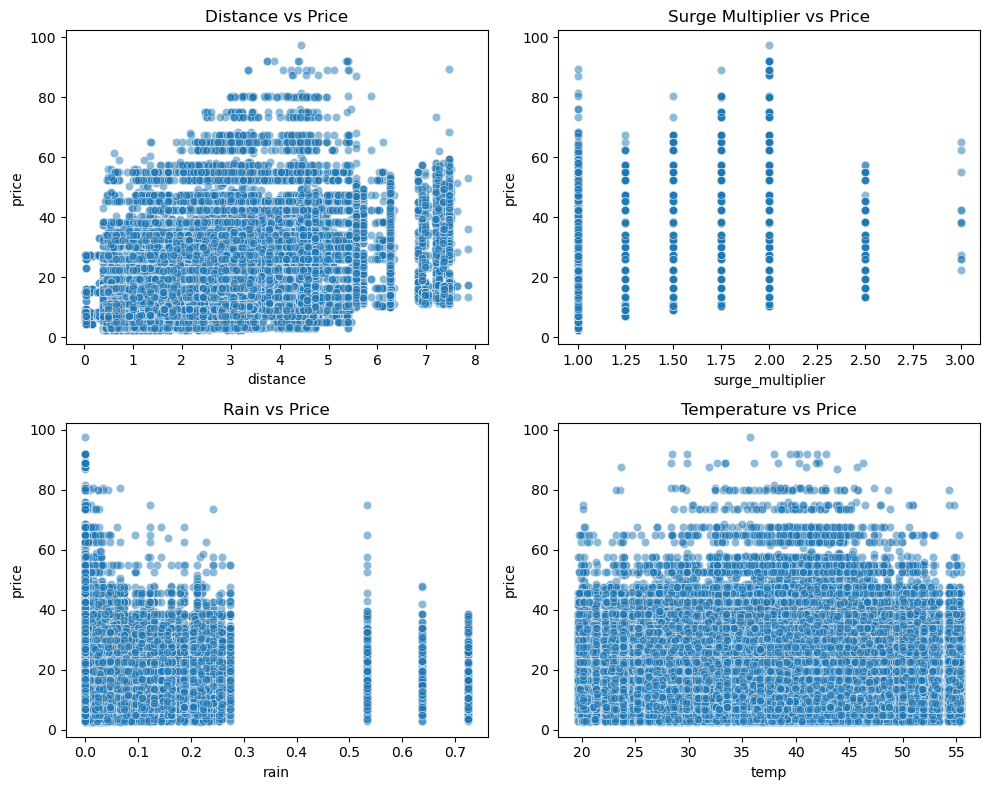

In [18]:
plt.figure(figsize=(10, 8))

plt.subplot(2, 2, 1)
sns.scatterplot(data=final_df, x='distance', y='price', alpha=0.5)
plt.title('Distance vs Price')

plt.subplot(2, 2, 2)
sns.scatterplot(data=final_df, x='surge_multiplier', y='price', alpha=0.5)
plt.title('Surge Multiplier vs Price')

plt.subplot(2, 2, 3)
sns.scatterplot(data=final_df, x='rain', y='price', alpha=0.5)
plt.title('Rain vs Price')

plt.subplot(2, 2, 4)
sns.scatterplot(data=final_df, x='temp', y='price', alpha=0.5)
plt.title('Temperature vs Price')

plt.tight_layout()
plt.show()

Conclusion & Analysis :
Weather (Rain & Temp): You correctly noticed that the weather features don't show a direct linear relationship with price. High prices still happen even when there is zero rain or normal temperatures.

Distance: Distance clearly drives the price up, but because it spreads out broadly and doesn't form a perfectly straight diagonal line, it confirms the relationship is non-linear. This is exactly why a standard Linear Regression model would struggle here, making your choice of a Random Forest Regressor perfect.

Surge Multiplier: On a scatter plot, surge multiplier looks like distinct vertical columns (1.0, 1.25, 1.5, etc.). If you look closely at those columns, you will notice that as the surge multiplier increases, the minimum price floor steps up significantly.

Step 8: Separate Features (X) and Target (y)

In [19]:
y = final_df['price']

text_and_time_cols = final_df.select_dtypes(include=['object', 'datetime64[ns]']).columns.tolist()
cols_to_drop = text_and_time_cols + ['price', 'time_stamp', 'time_hour']

X = final_df.drop(columns=list(set(cols_to_drop)), errors='ignore')

C:\Users\Dhruv\AppData\Local\Temp\ipykernel_21492\2428944685.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_and_time_cols = final_df.select_dtypes(include=['object', 'datetime64[ns]']).columns.tolist()


Step 9: Split the Dataset

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training features shape:", X_train.shape)
print("Testing features shape:", X_test.shape)

Training features shape: (510380, 29)
Testing features shape: (127596, 29)


Step 10: Initialize and Train the Random Forest Regressor

In [21]:
from sklearn.ensemble import RandomForestRegressor
regressor = RandomForestRegressor(n_estimators=20, random_state=42, n_jobs=-1)
regressor.fit(X_train, y_train)

print("Training complete!")

Training complete!


Step 11: Make Predictions

In [22]:
y_pred = regressor.predict(X_test)

Step 12: Evaluate the Model

In [23]:
from sklearn.metrics import mean_absolute_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n--- MODEL PERFORMANCE METRICS ---")
print(f"Mean Absolute Error (MAE): ${mae:.2f}")
print(f"R-squared (R2) Score: {r2 * 100:.2f}%")


--- MODEL PERFORMANCE METRICS ---
Mean Absolute Error (MAE): $1.27
R-squared (R2) Score: 95.68%


Step 13: Visualizing an Individual Decision Tree Structure

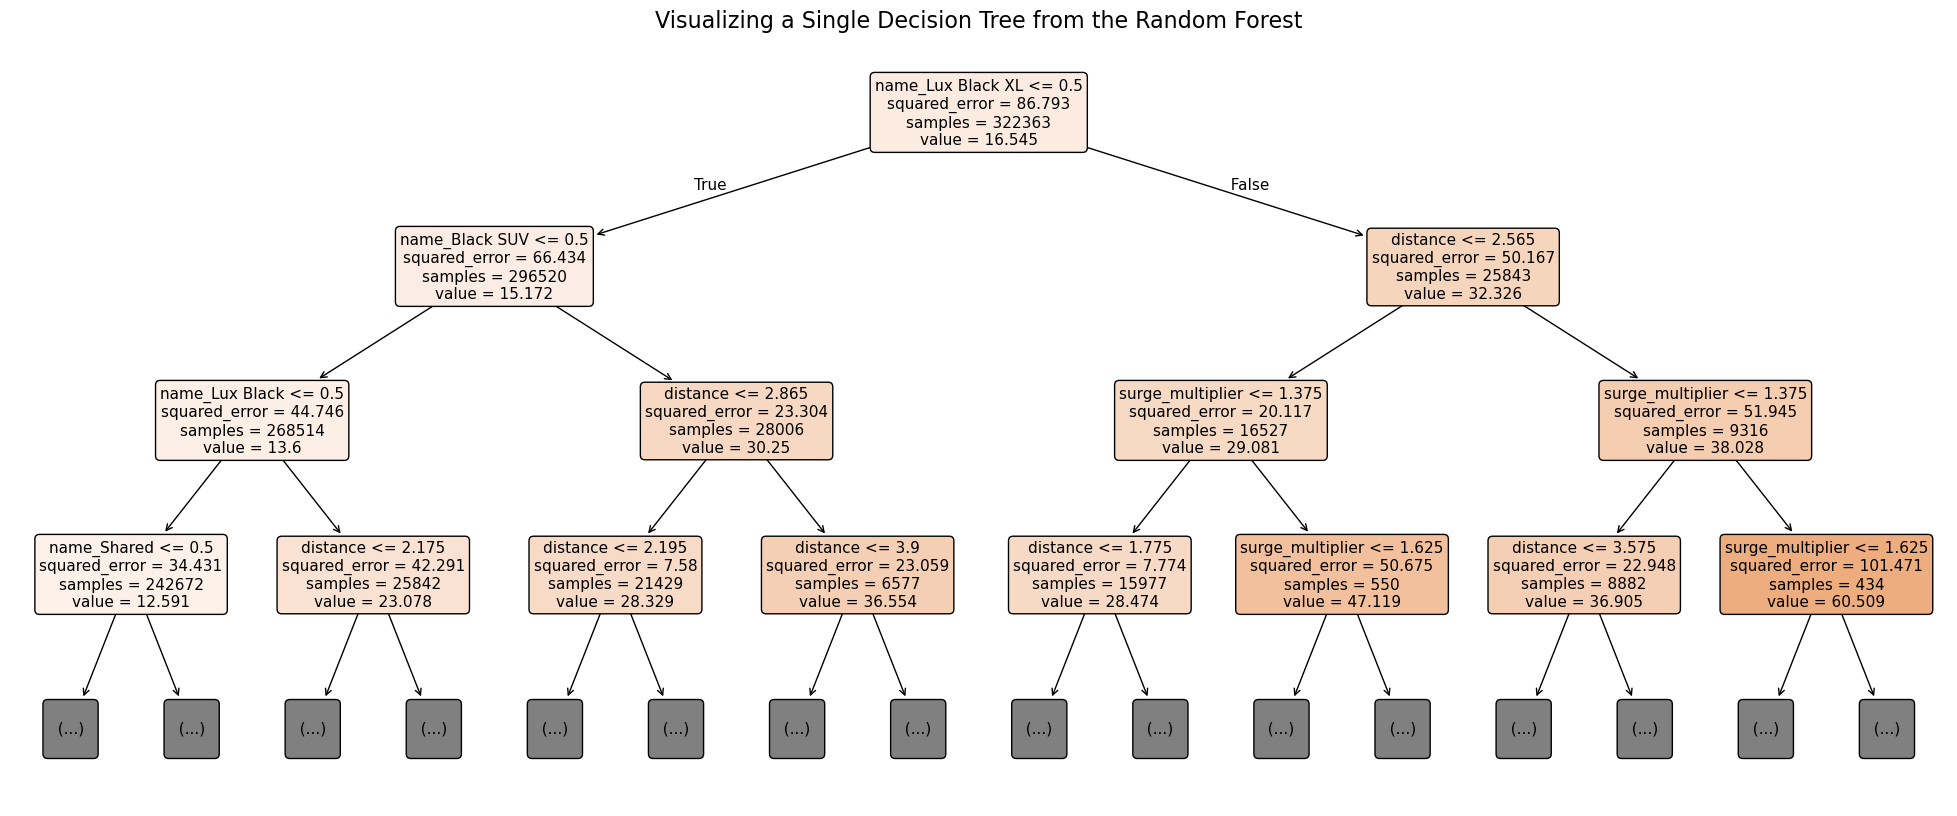

In [24]:
from sklearn.tree import plot_tree

sub_tree = regressor.estimators_[0]

plt.figure(figsize=(25, 10))

plot_tree(
    sub_tree, 
    max_depth=3, 
    feature_names=X.columns, 
    filled=True, 
    rounded=True, 
    fontsize=11
)

plt.title("Visualizing a Single Decision Tree from the Random Forest", fontsize=16)
plt.show()